In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
os.getcwd()

'C:\\Users\\mma'

In [3]:
dataset = pd.read_csv("spam.csv", encoding='latin-1')
dataset = dataset[['v1','v2']]
dataset.columns = ['label','message']
dataset.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
dataset.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
dataset['label'] = dataset['label'].map({'ham': 0, 'spam': 1})

In [7]:
dataset.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


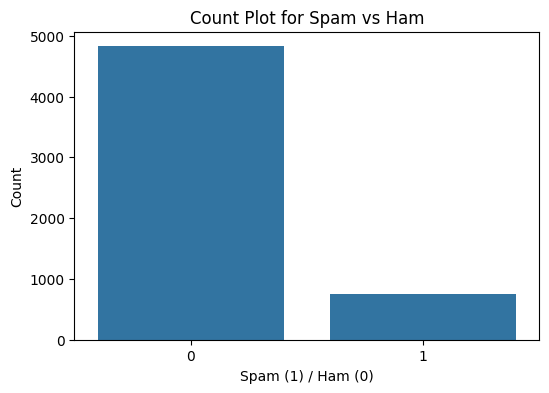

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=dataset)

plt.title("Count Plot for Spam vs Ham")
plt.xlabel("Spam (1) / Ham (0)")
plt.ylabel("Count")

plt.show()

In [11]:
dataset['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

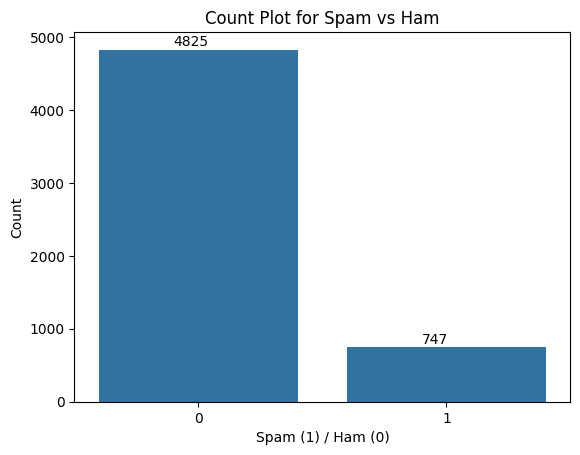

In [13]:
ax = sns.countplot(x='label', data=dataset)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + 0.3, p.get_height() + 50))

plt.title("Count Plot for Spam vs Ham")
plt.xlabel("Spam (1) / Ham (0)")
plt.ylabel("Count")

plt.show()

In [14]:
only_spam = dataset[dataset['label'] == 1]
len(only_spam)

747

In [15]:
len(dataset)

5572

In [16]:
# getting only spam messages
only_spam = dataset[dataset['label'] == 1]

# checking sizes
total_len = len(dataset)
spam_len = len(only_spam)

print("Total:", total_len)
print("Spam:", spam_len)

Total: 5572
Spam: 747


In [17]:
# calculating how many times to repeat spam data
count = int((total_len - spam_len) / spam_len)

print("Repeat spam this many times:", count)

Repeat spam this many times: 6


In [18]:
# balancing dataset by adding spam multiple times
for i in range(count):
    dataset = pd.concat([dataset, only_spam])

In [19]:
len(dataset)

10054

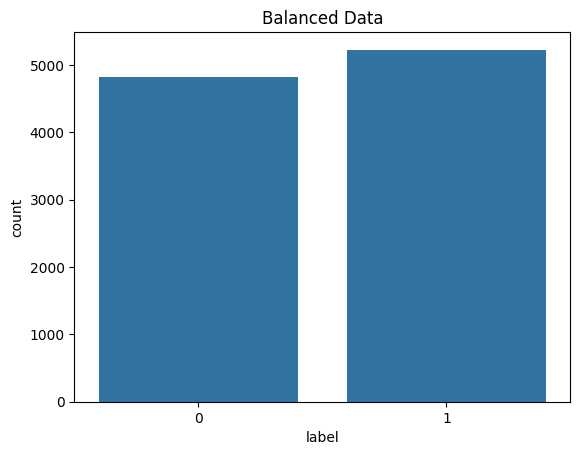

In [20]:
sns.countplot(x='label', data=dataset)
plt.title("Balanced Data")
plt.show()

In [21]:
# creating a new feature: word count

dataset['word_count'] = dataset['message'].apply(lambda x: len(x.split()))

# checking dataset
dataset.head()

,label,message,word_count
0,0,"Go until jurong point, crazy.. Available only ...",20
1,0,Ok lar... Joking wif u oni...,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,0,U dun say so early hor... U c already then say...,11
4,0,"Nah I don't think he goes to usf, he lives aro...",13


In [22]:
dataset[['label','word_count']].head()

,label,word_count
0,0,20
1,0,6
2,1,28
3,0,11
4,0,13


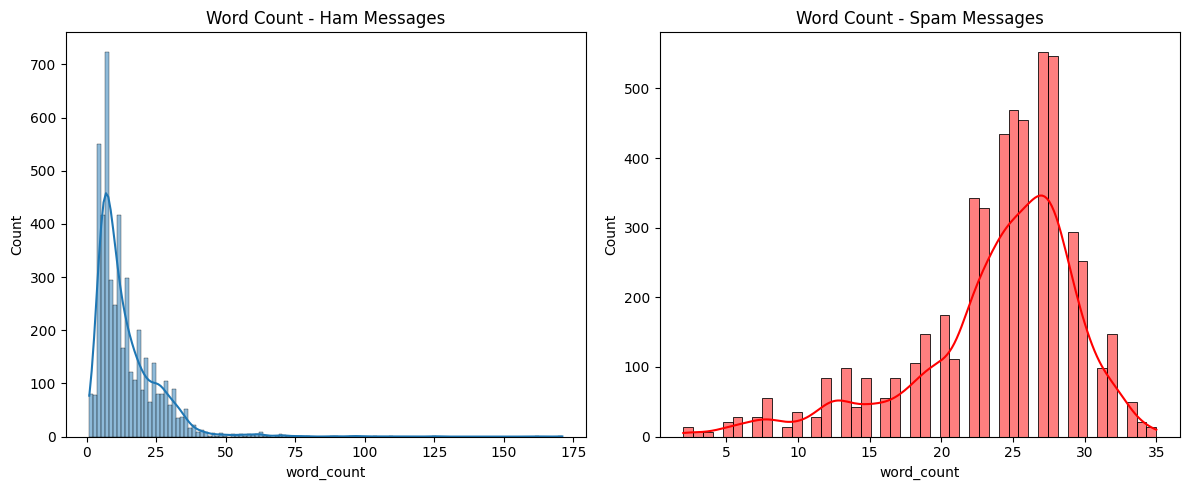

In [23]:
# visualizing word count distribution

plt.figure(figsize=(12,5))

# for ham (0)
plt.subplot(1,2,1)
sns.histplot(dataset[dataset['label'] == 0]['word_count'], kde=True)
plt.title("Word Count - Ham Messages")

# for spam (1)
plt.subplot(1,2,2)
sns.histplot(dataset[dataset['label'] == 1]['word_count'], kde=True, color='red')
plt.title("Word Count - Spam Messages")

plt.tight_layout()
plt.show()

In [24]:
# function to check currency symbols

def contains_currency(text):
    symbols = ['₹', '$', '€']
    
    for s in symbols:
        if s in text:
            return 1
    return 0


# applying to dataset
dataset['has_currency'] = dataset['message'].apply(contains_currency)

dataset.head()

,label,message,word_count,has_currency
0,0,"Go until jurong point, crazy.. Available only ...",20,0
1,0,Ok lar... Joking wif u oni...,6,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0
3,0,U dun say so early hor... U c already then say...,11,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0


In [25]:
dataset['has_currency'].value_counts()

has_currency
0    10012
1       42
Name: count, dtype: int64

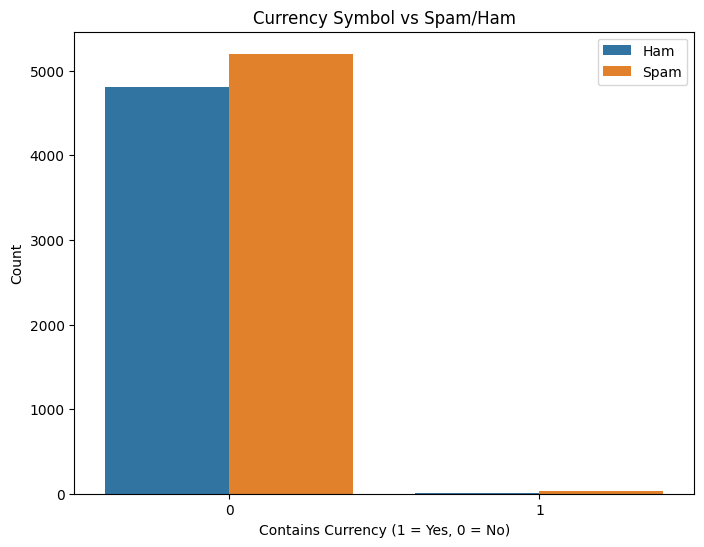

In [26]:
plt.figure(figsize=(8,6))

sns.countplot(x='has_currency', hue='label', data=dataset)

plt.title("Currency Symbol vs Spam/Ham")
plt.xlabel("Contains Currency (1 = Yes, 0 = No)")
plt.ylabel("Count")

plt.legend(labels=["Ham","Spam"])

plt.show()

In [27]:
# function to check if message contains numbers

def contains_number(text):
    for ch in text:
        if ch.isdigit():
            return 1
    return 0


# applying to dataset
dataset['has_number'] = dataset['message'].apply(contains_number)

dataset.head()

,label,message,word_count,has_currency,has_number
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,1
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0


In [28]:
dataset['has_number'].value_counts()

has_number
1    5704
0    4350
Name: count, dtype: int64

In [30]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mma\AppData\Roaming\nltk_data...


True

In [37]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# initialize
lemmatizer = WordNetLemmatizer()
corpus = []

for msg in dataset['message']:
    
    # remove special chars & numbers
    text = re.sub('[^a-zA-Z]', ' ', msg)
    
    # lowercase
    text = text.lower()
    
    # tokenize
    words = text.split()
    
    # remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stopwords.words('english')]
    
    # join back
    text = ' '.join(words)
    
    corpus.append(text)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

X = tfidf.fit_transform(corpus).toarray()
y = dataset['label']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [35]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       988
           1       0.88      0.94      0.91      1023

    accuracy                           0.90      2011
   macro avg       0.91      0.90      0.90      2011
weighted avg       0.91      0.90      0.90      2011



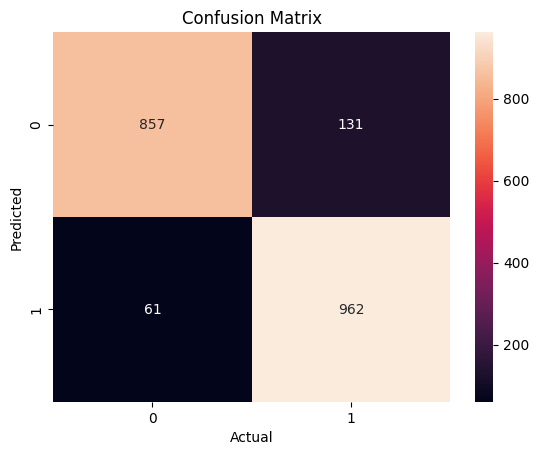

In [36]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")

plt.show()

In [38]:
X.shape

(10054, 500)

In [45]:
def predict_spam(msg):
    import re
    
    text = re.sub('[^a-zA-Z0-9]', ' ', msg)
    text = text.lower()
    words = text.split()
    
    words = [lemmatizer.lemmatize(w) for w in words if w not in stopwords.words('english')]
    
    text = ' '.join(words)
    
    temp = tfidf.transform([text]).toarray()
    
    result = model.predict(temp)[0]
    
    if result == 1:
        return "Spam"
    else:
        return "Ham"

In [42]:
predict_spam("Congratulations! You won 1000 rupees cash prize")

'Spam'

In [44]:
predict_spam("Congratulations! You won 5000 rupees. Call now!")

'Spam'